# Détection : les règles ou un modèle ?

Le projet signale aujourd'hui les marchés atypiques par des **règles** : un montant trop éloigné de
la médiane de sa famille d'achat. L'ADR 0006 a pris un engagement, il faut le tenir : on ne reste
sur cette marche que si une mesure montre qu'un modèle ne fait pas mieux.

Ce notebook fait la mesure. Il se rejoue tel quel, et les réglages à manipuler en direct sont
signalés par un commentaire `A MODIFIER`.

1. charger et regarder les données
2. fixer le protocole de comparaison
3. vérifier que deux exécutions donnent le même résultat
4. premier essai, Isolation Forest
5. comprendre le résultat
6. corriger
7. banc d'essai complet
8. sensibilité aux hyperparamètres
9. bilan

In [1]:
import sys
import time

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

sys.path.append("..")
from mesures.figures import (  # noqa: E402
    GRIS,
    SERIE_1,
    SERIE_2,
    SERIE_3,
    SERIE_4,
    legender,
    soigner,
)

%matplotlib inline

GRAINE = 42  # une seule graine pour tout le notebook
con = duckdb.connect("../donnees/commande_publique.duckdb", read_only=True)

## 1. Les données

Je pars de la couche argent, celle qui est nettoyee mais qui garde tout. Trois variables sont
construites ici : l'ecart de prix a la famille d'achat, le montant par mois, et l'etiquette.

L'**etiquette** est faible : c'est le producteur des donnees qui marque lui-meme certains montants
comme douteux. Ce n'est pas une verite de reference, c'est le seul repere qui existe.

In [2]:
# Ecrit en SQL et pas en pandas : DuckDB agrege deux millions de lignes sans les charger en
# memoire, et le calcul des medianes par famille tient en une clause.
REQUETE = """
with base as (
    select
        uid,
        montant,
        log10(montant)                          as montant_log10,
        montant_anomalie is not null            as signale_par_le_producteur,
        coalesce(dureeMois, 0)                  as duree_mois,
        coalesce(offresRecues, 0)               as offres_recues,
        case
            when regexp_matches(coalesce(trim(codeCPV), ''), '^[0-9]{2}')
                then substr(trim(codeCPV), 1, 2)
        end as famille_cpv
    from argent_marches
    -- Bornes de sanite mesurees en phase 2 : au-dela de mille milliards c'est une erreur de
    -- saisie, pas un marche.
    where montant > 0 and montant <= 1e12
),
statistiques as (
    select
        famille_cpv,
        count(*)                                as marches_dans_la_famille,
        median(montant_log10)                   as mediane_log,
        quantile_cont(montant_log10, 0.25)      as q1_log,
        quantile_cont(montant_log10, 0.75)      as q3_log,
        avg(montant_log10)                      as moyenne_log,
        stddev_samp(montant_log10)              as ecart_type_log
    from base
    where famille_cpv is not null
    group by 1
)
select
    b.signale_par_le_producteur,
    b.montant_log10,
    b.duree_mois,
    b.offres_recues,
    -- Ecart normalise robuste : mediane et ecart interquartile plutot que moyenne et ecart type,
    -- parce que l'ecart type est fausse par les valeurs extremes que l'on cherche justement.
    -- Le facteur 1,349 le rend comparable a un score z usuel.
    case
        when s.q3_log - s.q1_log > 0
            then (b.montant_log10 - s.mediane_log) / ((s.q3_log - s.q1_log) / 1.349)
        else 0
    end as ecart_normalise,
    -- La meme chose avec moyenne et ecart type : gardee pour mesurer en section 7 ce que la
    -- version robuste apporte vraiment.
    (b.montant_log10 - s.moyenne_log) / nullif(s.ecart_type_log, 0) as ecart_non_robuste,
    -- Deux marches de meme montant n'engagent pas la meme depense annuelle. Le modele pourra
    -- s'en servir, la regle de prix ne le fait pas.
    case when b.duree_mois > 0 then log10(b.montant / b.duree_mois) else b.montant_log10 end
        as montant_par_mois_log10
from base b
join statistiques s using (famille_cpv)
-- Moins de trente marches dans une famille : la mediane n'y veut plus rien dire.
where s.marches_dans_la_famille >= 30
"""

debut = time.perf_counter()
jeu = con.sql(REQUETE).df()
print(f"{len(jeu):,} marches lus en {time.perf_counter() - debut:.1f} s".replace(",", " "))
jeu.head()

2 053 765 marches lus en 0.2 s


,signale_par_le_producteur,montant_log10,duree_mois,offres_recues,ecart_normalise,ecart_non_robuste,montant_par_mois_log10
0,False,4.954243,44,6,-0.072462,-0.050407,3.310790
1,False,5.602060,48,5,1.100231,0.794082,3.920819
2,False,5.602060,48,5,1.100231,0.794082,3.920819
3,False,5.068287,2,1,-0.157156,-0.223778,4.767257
4,False,5.068287,2,1,-0.157156,-0.223778,4.767257


Avant toute statistique : la forme, les types, les valeurs manquantes.

In [3]:
jeu.info(memory_usage="deep")
print("\nvaleurs manquantes :")
print(jeu.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 2053765 entries, 0 to 2053764
Data columns (total 7 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   signale_par_le_producteur  bool   
 1   montant_log10              float64
 2   duree_mois                 int16  
 3   offres_recues              int16  
 4   ecart_normalise            float64
 5   ecart_non_robuste          float64
 6   montant_par_mois_log10     float64
dtypes: bool(1), float64(4), int16(2)
memory usage: 72.5 MB

valeurs manquantes :
signale_par_le_producteur    0
montant_log10                0
duree_mois                   0
offres_recues                0
ecart_normalise              0
ecart_non_robuste            0
montant_par_mois_log10       0
dtype: int64


In [4]:
# Les quantiles 1 % et 99 % disent plus que le min et le max, qui ne decrivent qu'une ligne.
jeu.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.round(2)

,count,mean,std,min,1%,25%,50%,75%,99%,max
montant_log10,2053765.0,5.14,0.92,-2.00,2.51,4.70,5.10,5.60,7.37,11.00
duree_mois,2053765.0,28.24,94.15,-1164.00,1.00,10.00,24.00,48.00,93.00,32000.00
offres_recues,2053765.0,3.66,32.48,-8.00,0.00,0.00,0.00,3.00,51.00,20300.00
ecart_normalise,2053765.0,0.05,1.34,-26.27,-3.72,-0.60,0.00,0.74,3.28,12.57
ecart_non_robuste,2053765.0,-0.00,1.00,-9.02,-2.74,-0.51,-0.04,0.53,2.53,7.81
montant_par_mois_log10,2053765.0,3.88,0.91,-4.62,1.30,3.42,3.88,4.40,5.88,11.00


Trois choses à retenir de ce tableau.

- L'étiquette est **rare**, autour de 3 %. Un modèle qui ne signalerait jamais rien aurait 97 % de
  bonnes réponses : le taux de bonnes réponses est donc inutilisable ici.
- `offres_recues` a une médiane à 0 : l'information manque plus d'une fois sur deux. Le 0 veut dire
  « non renseigné », pas « aucune offre ».
- `ecart_normalise` s'étend **des deux côtés** de zéro. C'est ce détail qui expliquera tout le
  notebook, mais il faut la section 5 pour le voir.

In [5]:
VARIABLES = [
    "ecart_normalise",
    "montant_log10",
    "montant_par_mois_log10",
    "duree_mois",
    "offres_recues",
]
# Deux variables tres correlees apportent la meme information.
jeu[VARIABLES].corr().round(2)

,ecart_normalise,montant_log10,montant_par_mois_log10,duree_mois,offres_recues
ecart_normalise,1.00,0.98,0.84,0.06,-0.10
montant_log10,0.98,1.00,0.87,0.05,-0.11
montant_par_mois_log10,0.84,0.87,1.00,-0.07,-0.12
duree_mois,0.06,0.05,-0.07,1.00,0.01
offres_recues,-0.10,-0.11,-0.12,0.01,1.00


La corrélation la plus forte est celle entre `ecart_normalise` et `montant_log10` : 0,98. Autrement
dit, **l'écart à la famille d'achat est presque le montant brut**. Les familles ont beau avoir des
médianes différentes, cela ne suffit pas à découpler les deux.

C'est une information à garder pour la suite : si l'étiquette est elle aussi un détecteur de gros
montants, alors classer par montant brut ressemblera beaucoup à classer par écart. La section 7 le
mesurera.

`montant_par_mois_log10` est corrélée à 0,87 au montant, ce qui est attendu puisqu'elle en est le
quotient par une durée. Je garde les deux : leur écart porte l'information sur les marchés longs.
Une corrélation forte gênerait un modèle linéaire ; Isolation Forest découpe variable par variable
et s'en accommode.

## 2. Le protocole

Une règle signale 8 331 marchés. Un modèle en signale autant qu'on veut selon l'endroit où l'on
coupe son score. Comparer leurs précisions telles quelles n'a donc aucun sens.

> **Budget d'alertes égal** : pour un nombre d'alertes donné, on prend les N marchés les mieux
> classés par chaque méthode et on compare leur précision.

C'est aussi la vraie contrainte du terrain : un analyste n'a pas un temps infini.

| Métrique | Ce qu'elle dit |
|---|---|
| précision à budget | part de vrais parmi les N premiers |
| précision moyenne (AP) | qualité du classement entier, adaptée aux classes rares |
| ROC AUC | montrée pour être critiquée : elle reste flatteuse quand les positifs sont rares |
| durée | un modèle qui demande des heures ne tient pas sur un VPS à 12 euros |

Le **hasard** sert de garde-fou : sans lui, on ne saurait pas si 3 % de précision est un résultat
ou le simple reflet de la fréquence de l'étiquette.

In [6]:
from sklearn.metrics import average_precision_score, roc_auc_score


def precision_au_budget(scores: np.ndarray, etiquettes: np.ndarray, budget: int) -> float:
    """Part de marches reellement signales parmi les `budget` marches les mieux classes."""
    if budget > len(scores):
        return float("nan")
    # argpartition trouve les N plus grands sans trier les deux millions d'autres.
    indices = np.argpartition(-scores, budget - 1)[:budget]
    return round(100 * float(etiquettes[indices].mean()), 1)


# --- A MODIFIER : les budgets compares ---------------------------------------
BUDGETS = [100, 500, 1000, 5000, 10000, 30000]
# -----------------------------------------------------------------------------

## 3. Deux exécutions donnent-elles le même résultat ?

Question posée avant de mesurer quoi que ce soit. Elle a l'air théorique ; elle ne l'est pas.

In [7]:
def charger(tri: str = "") -> pd.DataFrame:
    """Relit le jeu, avec ou sans clause de tri."""
    return con.sql(REQUETE + (f"\n{tri}" if tri else "")).df()


def empreinte(tableau: np.ndarray) -> str:
    """Resume un tableau en quelques caracteres, pour comparer deux executions d'un coup d'oeil."""
    import hashlib

    return hashlib.sha256(np.ascontiguousarray(tableau).tobytes()).hexdigest()[:12]


a, b = charger(), charger()
print(f"memes lignes : {len(a) == len(b)}")
print(f"empreinte de la matrice, chargement 1 : {empreinte(a[VARIABLES].to_numpy())}")
print(f"empreinte de la matrice, chargement 2 : {empreinte(b[VARIABLES].to_numpy())}")

memes lignes : True
empreinte de la matrice, chargement 1 : ed6a5990fef9
empreinte de la matrice, chargement 2 : cd8108dbc53b


Deux chargements de la même requête sur la même base ne donnent pas la même matrice. DuckDB
travaille en parallèle et ne garantit aucun ordre de lignes sans `order by`.

Est-ce que ça change une mesure ? C'est la seule question qui compte.

In [8]:
def precision_du_modele(donnees: pd.DataFrame, budget: int = 100) -> float:
    """Entraine le modele sur un chargement donne et renvoie sa precision a `budget` alertes."""
    X = donnees[VARIABLES].to_numpy(dtype=np.float32)
    scores = (
        -IsolationForest(n_estimators=100, max_samples=256, random_state=GRAINE, n_jobs=-1)
        .fit(X)
        .score_samples(X)
    )
    # On regarde le cote « montant eleve », celui de la regle. La section 6 dira pourquoi.
    scores = np.where(donnees["ecart_normalise"].to_numpy() > 0, scores, -np.inf)
    return precision_au_budget(scores, donnees["signale_par_le_producteur"].to_numpy(), budget)


print(f"precision a 100 alertes, chargement 1 : {precision_du_modele(a)} %")
print(f"precision a 100 alertes, chargement 2 : {precision_du_modele(b)} %")

precision a 100 alertes, chargement 1 : 100.0 %


precision a 100 alertes, chargement 2 : 73.0 %


Le même code, la même graine, les mêmes données, et deux résultats. Le modèle tire ses échantillons
**par position** : changer l'ordre des lignes change le modèle.

Premier réflexe, trier sur l'identifiant.

In [9]:
a, b = charger("order by uid"), charger("order by uid")
print(f"empreintes : {empreinte(a[VARIABLES].to_numpy())} / {empreinte(b[VARIABLES].to_numpy())}")
print(f"precision  : {precision_du_modele(a)} % / {precision_du_modele(b)} %")

empreintes : bd79d740a994 / 335a503653a8


precision  : 73.0 % / 99.0 %


Les empreintes diffèrent encore. La précision tombe juste cette fois, mais c'est une coïncidence :
tant que la matrice change, rien n'est garanti. Donc `uid` ne suffit pas à désigner une ligne.
Vérifions.

In [10]:
print(
    con.sql("""
    select count(*) as lignes,
           count(distinct uid) as uid_distincts,
           count(*) - count(distinct uid) as lignes_en_trop
    from argent_marches where montant > 0 and montant <= 1e12
""")
    .df()
    .to_string(index=False)
)

print("\nuid apparaissant plusieurs fois :")
print(
    con.sql("""
    select count(*) as uid_repetes,
           sum(case when montants_differents > 1 then 1 else 0 end) as dont_montants_contradictoires
    from (
        select uid, count(distinct montant) as montants_differents
        from argent_marches where montant > 0 and montant <= 1e12
        group by 1 having count(*) > 1
    )
""")
    .df()
    .to_string(index=False)
)

 lignes  uid_distincts  lignes_en_trop
2054924        1773520          281404

uid apparaissant plusieurs fois :


 uid_repetes  dont_montants_contradictoires
      140350                          619.0


**`uid` identifie un marché, pas une ligne.** Un marché a autant de lignes que de titulaires, d'où
les répétitions. Et une petite partie de ces marchés porte des montants contradictoires d'une ligne
à l'autre, ce qui est un vrai défaut de qualité à signaler.

Conséquence ici : trier sur `uid` laisse encore permuter les lignes d'un même marché. Le tri doit
porter sur toutes les colonnes utilisées.

In [11]:
TRI = (
    "order by uid, montant_log10, ecart_normalise, montant_par_mois_log10,"
    " duree_mois, offres_recues, signale_par_le_producteur"
)

a, b = charger(TRI), charger(TRI)
print(f"empreintes : {empreinte(a[VARIABLES].to_numpy())} / {empreinte(b[VARIABLES].to_numpy())}")
print(f"precision  : {precision_du_modele(a)} % / {precision_du_modele(b)} %")

# Le jeu de travail pour tout le reste du notebook.
jeu = a
etiquettes = jeu["signale_par_le_producteur"].to_numpy()
matrice = jeu[VARIABLES].to_numpy(dtype=np.float32)
score_regle = jeu["ecart_normalise"].to_numpy()
score_hasard = np.random.default_rng(GRAINE).random(len(jeu))
cote_montant_eleve = score_regle > 0

empreintes : 7a59792c071f / 7a59792c071f


precision  : 73.0 % / 73.0 %


Reproductible. La leçon tient en une phrase, et elle vaut pour tout le projet : **une graine fixe
ne suffit pas, il faut aussi un ordre de lignes fixe.**

Reste une limite qu'aucun tri ne corrige : les scores d'Isolation Forest comportent beaucoup
d'ex aequo, donc une précision mesurée sur un très petit budget reste fragile. Mesurons-la.

In [12]:
scores_provisoires = (
    -IsolationForest(n_estimators=100, max_samples=256, random_state=GRAINE, n_jobs=-1)
    .fit(matrice)
    .score_samples(matrice)
)
tries = np.sort(scores_provisoires)[::-1]

print(
    f"valeurs de score distinctes : {len(np.unique(scores_provisoires)):,} "
    f"pour {len(jeu):,} marches".replace(",", " ")
)
for budget in (100, 1000):
    ex_aequo = int((scores_provisoires >= tries[budget - 1]).sum())
    print(f"marches a egalite avec le {budget}e score : {ex_aequo:,}".replace(",", " "))

valeurs de score distinctes : 419 008 pour 2 053 765 marches
marches a egalite avec le 100e score : 491
marches a egalite avec le 1000e score : 1 626


Il y a plus de candidats que de places. Les colonnes des petits budgets sont donc à lire comme des
ordres de grandeur, pas comme des chiffres au dixième près.

## 4. Premier essai

Pourquoi Isolation Forest : il est conçu pour l'anomalie, son coût est linéaire, il supporte des
variables d'échelles très différentes et demande peu de réglages. Son principe tient en une ligne :
on découpe l'espace au hasard, et **une anomalie est isolée en peu de découpes** parce qu'elle est
loin des autres.

Les alternatives ne sont pas écartées sur parole : elles passent toutes au banc d'essai en
section 7.

In [13]:
# --- A MODIFIER : les hyperparametres ----------------------------------------
# max_samples=256 est la valeur recommandee par les auteurs : une anomalie se detecte sur un petit
# echantillon, en ajouter dilue le signal. La section 8 le verifie.
HYPERPARAMETRES = dict(n_estimators=100, max_samples=256, random_state=GRAINE, n_jobs=-1)
# -----------------------------------------------------------------------------

debut = time.perf_counter()
foret = IsolationForest(**HYPERPARAMETRES).fit(matrice)
duree_entrainement = time.perf_counter() - debut

debut = time.perf_counter()
# score_samples renvoie un score d'autant plus BAS que l'observation est anormale : on l'inverse
# pour que toutes les methodes se lisent dans le meme sens.
score_modele = -foret.score_samples(matrice)
duree_modele = duree_entrainement + (time.perf_counter() - debut)
print(f"{len(jeu):,} marches, entraine et applique en {duree_modele:.1f} s".replace(",", " "))

2 053 765 marches  entraine et applique en 4.6 s


In [14]:
comparaison = pd.DataFrame(
    {
        "regle": [precision_au_budget(score_regle, etiquettes, b) for b in BUDGETS],
        "modele": [precision_au_budget(score_modele, etiquettes, b) for b in BUDGETS],
        "hasard": [precision_au_budget(score_hasard, etiquettes, b) for b in BUDGETS],
    },
    index=pd.Index(BUDGETS, name="budget d'alertes"),
)
comparaison

,regle,modele,hasard
budget d'alertes,,,
100,96.0,0.0,2.0
500,98.0,0.0,2.8
1000,96.1,0.0,3.1
5000,87.5,1.1,2.8
10000,73.3,1.7,2.7
30000,56.4,25.6,2.6


Le modèle est à zéro sur les petits budgets, c'est-à-dire **sous le hasard**. La conclusion facile
serait « les règles gagnent ». Un modèle sous le hasard ne se trompe pas au hasard : il range les
marchés selon un critère systématiquement différent. Il faut regarder lesquels.

## 5. Qui le modèle désigne-t-il ?

In [15]:
def profil(scores: np.ndarray, budget: int = 1000) -> pd.Series:
    """Portrait median des `budget` marches les mieux classes."""
    selection = jeu.iloc[np.argpartition(-scores, budget - 1)[:budget]]
    return pd.Series(
        {
            "ecart normalise median": selection["ecart_normalise"].median(),
            "montant median (euros)": 10 ** selection["montant_log10"].median(),
            "duree mediane (mois)": selection["duree_mois"].median(),
            "offres recues medianes": selection["offres_recues"].median(),
            "part signalee (%)": 100 * selection["signale_par_le_producteur"].mean(),
        }
    )


pd.DataFrame(
    {
        "les 1000 de la regle": profil(score_regle),
        "les 1000 du modele": profil(score_modele),
        "tout le jeu": profil(np.ones(len(jeu)), budget=len(jeu)),
    }
).round(1)

,les 1000 de la regle,les 1000 du modele,tout le jeu
ecart normalise median,6.800000e+00,-8.2,0.0
montant median (euros),4.000000e+09,0.2,126473.0
duree mediane (mois),4.800000e+01,84.0,24.0
offres recues medianes,0.000000e+00,468.0,0.0
part signalee (%),9.610000e+01,0.0,2.7


**Voilà l'explication.** L'écart médian des marchés du modèle est franchement négatif : des
montants anormalement **bas**. Celui de la règle est positif : des montants anormalement **hauts**.

Or l'étiquette est produite par un détecteur de montants trop grands. Elle ne marque jamais un
montant trop petit. Un modèle qui cherche de ce côté ne peut obtenir que zéro, quelle que soit sa
qualité. **La métrique ne mesurait pas le modèle, elle mesurait un désaccord de direction.**

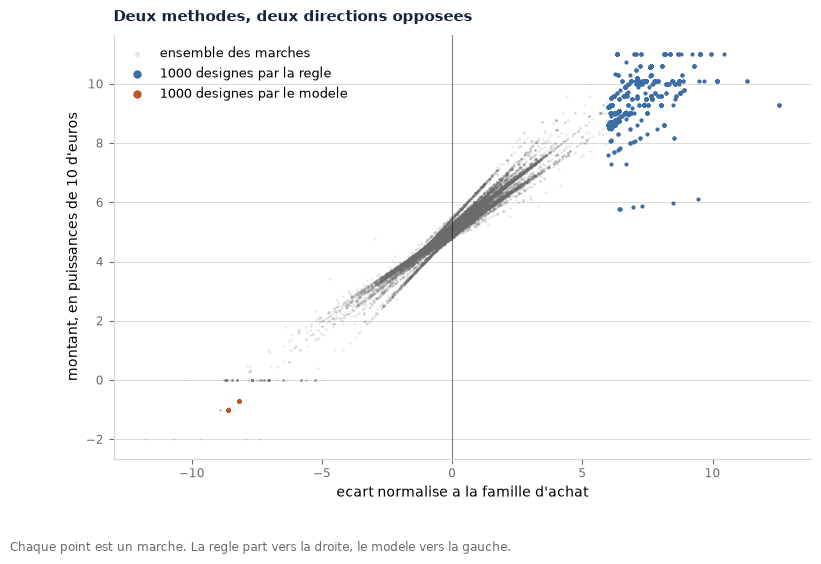

In [16]:
echantillon = jeu.sample(40_000, random_state=GRAINE)

figure, axes = plt.subplots(figsize=(9, 5.5))
axes.scatter(
    echantillon["ecart_normalise"],
    echantillon["montant_log10"],
    s=3,
    c=GRIS,
    alpha=0.18,
    linewidths=0,
    rasterized=True,
    label="ensemble des marches",
)
for scores, couleur, nom in (
    (score_regle, SERIE_1, "1000 designes par la regle"),
    (score_modele, SERIE_2, "1000 designes par le modele"),
):
    haut = jeu.iloc[np.argpartition(-scores, 999)[:1000]]
    axes.scatter(
        haut["ecart_normalise"],
        haut["montant_log10"],
        s=9,
        c=couleur,
        linewidths=0,
        rasterized=True,
        label=nom,
    )

axes.axvline(0, color="black", linewidth=0.8, alpha=0.5)
axes.set_xlabel("ecart normalise a la famille d'achat")
axes.set_ylabel("montant, en puissances de 10 d'euros")
axes.legend(loc="upper left", frameon=False, fontsize=9, markerscale=2)
soigner(axes, "Deux methodes, deux directions opposees")
legender(
    figure, "Chaque point est un marche. La regle part vers la droite, le modele vers la gauche."
)
plt.show()

Deux nuages presque disjoints. La leçon dépasse ce notebook : **une évaluation ne dit rien sur ce
que son étiquette ignore.** « Non validé » n'est pas « invalide ».

## 6. Corriger : orienter le modèle

Hypothèse : le modèle n'est pas moins performant, il est **aveugle à la direction**. Test : même
modèle, mêmes scores, on restreint ses candidats au côté « montant élevé ». Si l'hypothèse est
juste, sa précision doit remonter d'un coup.

Ce n'est pas tricher : c'est lui donner la connaissance métier que la règle contenait déjà en clair.

In [17]:
# On repousse en fin de classement les marches du mauvais cote. Aucun score n'est recalcule.
score_oriente = np.where(cote_montant_eleve, score_modele, -np.inf)

comparaison["modele oriente"] = [precision_au_budget(score_oriente, etiquettes, b) for b in BUDGETS]
comparaison = comparaison[["regle", "modele", "modele oriente", "hasard"]]
comparaison

,regle,modele,modele oriente,hasard
budget d'alertes,,,,
100,96.0,0.0,73.0,2.0
500,98.0,0.0,73.6,2.8
1000,96.1,0.0,65.7,3.1
5000,87.5,1.1,74.8,2.8
10000,73.3,1.7,70.9,2.7
30000,56.4,25.6,52.9,2.6


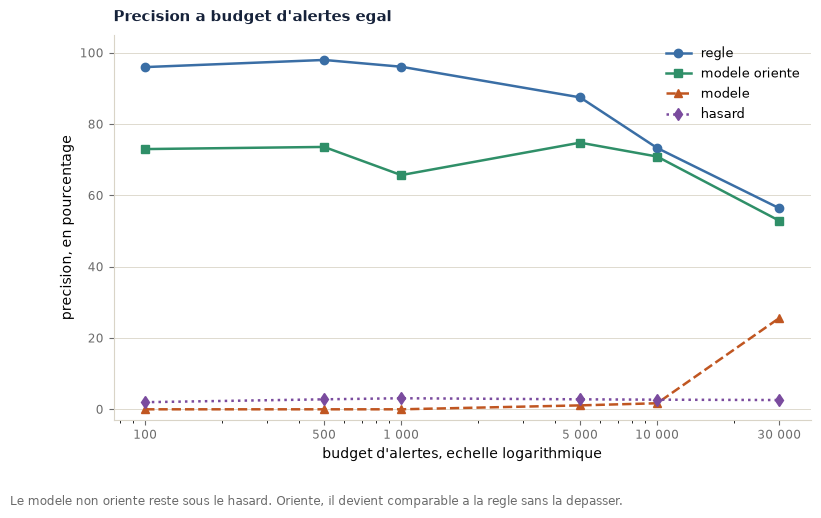

In [18]:
figure, axes = plt.subplots(figsize=(9, 5))
for nom, couleur, marqueur, trait in (
    ("regle", SERIE_1, "o", "-"),
    ("modele oriente", SERIE_3, "s", "-"),
    ("modele", SERIE_2, "^", "--"),
    ("hasard", SERIE_4, "d", ":"),
):
    axes.plot(
        comparaison.index,
        comparaison[nom],
        marker=marqueur,
        linestyle=trait,
        color=couleur,
        linewidth=1.8,
        markersize=6,
        label=nom,
    )

axes.set_xscale("log")
axes.set_xticks(BUDGETS)
axes.set_xticklabels([f"{b:,}".replace(",", " ") for b in BUDGETS])
axes.set_ylim(-3, 105)
axes.set_xlabel("budget d'alertes, echelle logarithmique")
axes.set_ylabel("precision, en pourcentage")
axes.legend(frameon=False, fontsize=9)
soigner(axes, "Precision a budget d'alertes egal")
legender(
    figure,
    "Le modele non oriente reste sous le hasard. Oriente, il devient comparable a la "
    "regle sans la depasser.",
)
plt.show()

## 7. Banc d'essai

Deux méthodes ne suffisent pas à écrire « nous avons choisi les règles ». Dix méthodes passent ici
sur le même jeu, avec les mêmes métriques, de la plus naïve à la plus élaborée. Trois sont des
versions que je crois mauvaises : elles restent, parce qu'un écart chiffré justifie mieux un choix
qu'une affirmation, et parce qu'il arrive que la mesure donne tort à l'intuition.

In [19]:
def evaluer(nom: str, scores: np.ndarray, duree: float, oriente: bool = False) -> dict:
    """Les quatre metriques retenues pour une methode."""
    if oriente:
        # On soustrait au minimum plutot que d'utiliser moins l'infini : scikit-learn accepte mal
        # les valeurs infinies, et le classement obtenu est le meme.
        scores = np.where(cote_montant_eleve, scores, np.min(scores) - 1.0)
    return {
        "methode": nom,
        "AP (%)": round(100 * average_precision_score(etiquettes, scores), 2),
        "ROC AUC (%)": round(100 * roc_auc_score(etiquettes, scores), 1),
        "P@100 (%)": precision_au_budget(scores, etiquettes, 100),
        "P@1000 (%)": precision_au_budget(scores, etiquettes, 1000),
        "P@10000 (%)": precision_au_budget(scores, etiquettes, 10000),
        "duree (s)": round(duree, 1),
    }


resultats, scores_gardes = [], {}


def ajouter(nom: str, scores: np.ndarray, duree: float) -> None:
    """Evalue une methode, garde son score pour le tableau oriente."""
    resultats.append(evaluer(nom, scores, duree))
    scores_gardes[nom] = scores

In [20]:
# --- Marches 1 a 3 : les statistiques, sans aucun apprentissage ---------------

# 1. Le z-score global : l'erreur classique, comparer un marche de voirie a des fournitures.
debut = time.perf_counter()
montants = jeu["montant_log10"].to_numpy()
ajouter(
    "1. z-score global", (montants - montants.mean()) / montants.std(), time.perf_counter() - debut
)

# 2. Le bon groupe de comparaison, mais moyenne et ecart type : l'outlier gonfle l'ecart type,
# donc se cache lui-meme. C'est l'effet de masquage.
debut = time.perf_counter()
ajouter(
    "2. z-score par famille",
    jeu["ecart_non_robuste"].fillna(0).to_numpy(),
    time.perf_counter() - debut,
)

# 3. La regle du projet : mediane et ecart interquartile, par famille.
ajouter("3. ecart robuste (regle)", score_regle, 0.0)

pd.DataFrame(resultats).set_index("methode")

,AP (%),ROC AUC (%),P@100 (%),P@1000 (%),P@10000 (%),duree (s)
methode,,,,,,
1. z-score global,49.66,95.3,100.0,95.5,80.3,0.0
2. z-score par famille,50.22,95.5,100.0,99.1,75.9,0.0
3. ecart robuste (regle),47.12,95.3,96.0,96.1,73.3,0.0


**Ce tableau dit le contraire de ce que j'attendais.** Les deux versions naïves font aussi bien que
la règle robuste, et même un peu mieux en précision moyenne. Le raisonnement sur le masquage, lui,
reste juste : une valeur extrême gonfle l'écart type et se cache. Mais il ne se voit pas ici.

L'explication est toujours la même, et c'est la limite centrale de ce notebook : **l'étiquette est
un détecteur de gros montants**. Classer par montant brut lui donne donc presque raison
d'avance. La section 1 l'avait annoncé : l'écart à la famille est corrélé à 0,98 au montant.

Ce que je peux conclure honnêtement : **cette étiquette ne sait pas départager ces trois
méthodes.** Elle valide la direction de recherche, pas la finesse du calcul. Départager demanderait
une étiquette qui ne vienne pas d'un détecteur de montants, donc un échantillon jugé à la main.
C'est le premier point de la liste « à mesurer ensuite ».

Je garde la version robuste, mais pour une raison qui n'est pas dans ce tableau : elle compare
chaque marché à ses pairs, et elle ne se laisse pas déplacer par les valeurs qu'elle cherche.

In [21]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.linear_model import SGDOneClassSVM
from sklearn.preprocessing import RobustScaler, StandardScaler

# Isolation Forest decoupe variable par variable : l'echelle lui est indifferente. Les methodes
# fondees sur une distance, non : sans normalisation elles ne regarderaient que `offres_recues`,
# qui monte a plusieurs milliers quand `ecart_normalise` tient dans une dizaine.
X_standard = StandardScaler().fit_transform(matrice)
X_robuste = RobustScaler().fit_transform(matrice)
print("amplitude maximale par variable")
print(f"  brut      {matrice.max(axis=0).round(1)}")
print(f"  robuste   {X_robuste.max(axis=0).round(1)}")

amplitude maximale par variable
  brut      [1.26e+01 1.10e+01 1.10e+01 3.20e+04 2.03e+04]
  robuste   [9.3000e+00 6.5000e+00 7.3000e+00 8.4150e+02 6.7667e+03]


In [22]:
# --- Marches 4 a 9 : les modeles ---------------------------------------------

# 4 et 5. Distance au centre le plus proche : un point loin de tout amas est atypique. Teste avec
# les deux normalisations, pour mesurer ce que ce seul choix change.
for nom, X in (
    ("4. k-moyennes, normalisation standard", X_standard),
    ("5. k-moyennes, normalisation robuste", X_robuste),
):
    debut = time.perf_counter()
    kmeans = MiniBatchKMeans(n_clusters=12, random_state=GRAINE, n_init=5, batch_size=4096).fit(X)
    ajouter(nom, kmeans.transform(X).min(axis=1), time.perf_counter() - debut)

# 6. Erreur de reconstruction par ACP : on comprime en deux dimensions puis on decomprime, et ce
# qui se reconstruit mal est atypique. C'est l'ancetre lineaire de l'autoencodeur.
debut = time.perf_counter()
acp = PCA(n_components=2, random_state=GRAINE).fit(X_robuste)
erreur = ((X_robuste - acp.inverse_transform(acp.transform(X_robuste))) ** 2).sum(axis=1)
ajouter("6. ACP, erreur de reconstruction", erreur, time.perf_counter() - debut)

# 7. Enveloppe elliptique : une gaussienne robuste, puis la distance de Mahalanobis. L'ajustement
# se fait sur 20 000 lignes parce que l'estimateur est iteratif et couteux ; le score porte sur
# tout le jeu.
debut = time.perf_counter()
tirage = np.random.default_rng(GRAINE).choice(len(X_robuste), 20_000, replace=False)
enveloppe = EllipticEnvelope(support_fraction=0.9, random_state=GRAINE).fit(X_robuste[tirage])
ajouter("7. enveloppe elliptique", enveloppe.mahalanobis(X_robuste), time.perf_counter() - debut)

# 8. SVM a une classe. La version exacte ne passe pas l'echelle ; cette approximation lineaire si.
debut = time.perf_counter()
svm = SGDOneClassSVM(nu=0.05, random_state=GRAINE, max_iter=20).fit(X_robuste)
ajouter("8. SVM a une classe", -svm.decision_function(X_robuste), time.perf_counter() - debut)

# 9. Isolation Forest, deja calcule en section 4.
ajouter("9. Isolation Forest", score_modele, duree_modele)

pd.DataFrame(resultats).set_index("methode").tail(6)

,AP (%),ROC AUC (%),P@100 (%),P@1000 (%),P@10000 (%),duree (s)
methode,,,,,,
"4. k-moyennes, normalisation standard",9.44,71.5,2.0,2.0,13.3,0.6
"5. k-moyennes, normalisation robuste",7.01,72.4,2.0,2.0,3.6,0.5
"6. ACP, erreur de reconstruction",19.86,90.3,2.0,10.1,4.9,0.1
7. enveloppe elliptique,6.33,78.3,2.0,2.0,3.3,1.7
8. SVM a une classe,4.27,46.0,1.0,65.8,23.2,0.9
9. Isolation Forest,17.46,88.8,0.0,0.0,1.7,4.6


Reste une méthode que j'avais écartée **sans la tester**, sur un argument de coût : Local Outlier
Factor compare chaque point à ses voisins, et sa complexité est réputée quadratique, donc
impraticable sur deux millions de lignes.

Un argument qui n'a pas été mesuré n'est pas un argument. Mesurons-le.

In [23]:
from sklearn.neighbors import LocalOutlierFactor

# Si le cout etait quadratique, la duree PAR LIGNE devrait augmenter avec la taille. Echantillons
# tires au hasard, et non les premieres lignes, qui sont triees donc pas representatives.
tirage = np.random.default_rng(GRAINE)
mesures = []
for taille in (25_000, 50_000, 100_000, 200_000, 400_000):
    extrait = X_robuste[tirage.choice(len(X_robuste), taille, replace=False)]
    debut = time.perf_counter()
    LocalOutlierFactor(n_neighbors=20, n_jobs=-1).fit_predict(extrait)
    mesures.append({"lignes": taille, "duree (s)": round(time.perf_counter() - debut, 2)})

cout = pd.DataFrame(mesures)
cout["duree par ligne (ms)"] = (1000 * cout["duree (s)"] / cout["lignes"]).round(4)
cout

/Users/elyserasoloarivony/Documents/Memoire-2026/memoire-1-commande-publique/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(
/Users/elyserasoloarivony/Documents/Memoire-2026/memoire-1-commande-publique/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


/Users/elyserasoloarivony/Documents/Memoire-2026/memoire-1-commande-publique/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


/Users/elyserasoloarivony/Documents/Memoire-2026/memoire-1-commande-publique/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


/Users/elyserasoloarivony/Documents/Memoire-2026/memoire-1-commande-publique/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,lignes,duree (s),duree par ligne (ms)
0,25000,0.09,0.0036
1,50000,0.19,0.0038
2,100000,0.38,0.0038
3,200000,0.81,0.0040
4,400000,2.06,0.0052


**La durée par ligne augmente de 60 % quand la taille est multipliée par 16.** Un coût quadratique
l'aurait multipliée par 16 elle aussi. Le coût n'est donc pas quadratique : sur cinq dimensions,
scikit-learn indexe les points dans un arbre et la recherche des voisins devient quasi linéaire. La
réputation de LOF vient de son comportement en grande dimension, où l'arbre ne sert plus à rien.

J'avais donc écarté une méthode sur une idée reçue. Elle tient sur le jeu complet : faisons-la
tourner pour de bon.

In [24]:
debut = time.perf_counter()
lof = LocalOutlierFactor(n_neighbors=20, n_jobs=-1)
lof.fit_predict(X_robuste)
# negative_outlier_factor_ est d'autant plus BAS que le point est atypique : on l'inverse.
ajouter("10. Local Outlier Factor", -lof.negative_outlier_factor_, time.perf_counter() - debut)

banc = pd.DataFrame(resultats).set_index("methode")
banc

/Users/elyserasoloarivony/Documents/Memoire-2026/memoire-1-commande-publique/.venv/lib/python3.12/site-packages/sklearn/neighbors/_lof.py:327: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


,AP (%),ROC AUC (%),P@100 (%),P@1000 (%),P@10000 (%),duree (s)
methode,,,,,,
1. z-score global,49.66,95.3,100.0,95.5,80.3,0.0
2. z-score par famille,50.22,95.5,100.0,99.1,75.9,0.0
3. ecart robuste (regle),47.12,95.3,96.0,96.1,73.3,0.0
"4. k-moyennes, normalisation standard",9.44,71.5,2.0,2.0,13.3,0.6
"5. k-moyennes, normalisation robuste",7.01,72.4,2.0,2.0,3.6,0.5
"6. ACP, erreur de reconstruction",19.86,90.3,2.0,10.1,4.9,0.1
7. enveloppe elliptique,6.33,78.3,2.0,2.0,3.3,1.7
8. SVM a une classe,4.27,46.0,1.0,65.8,23.2,0.9
9. Isolation Forest,17.46,88.8,0.0,0.0,1.7,4.6


Trois lectures de ce tableau.

**Les trois premières lignes écrasent les sept autres.** Aucune méthode apprise ne s'approche des
statistiques simples. Rappel de la section précédente : c'est en partie parce que l'étiquette les
avantage, mais l'écart est trop large pour n'être que cela.

**ROC AUC est bien la métrique trompeuse annoncée.** Les k-moyennes affichent 71,5 % d'AUC pour
2 % de précision à mille alertes. Avec 3 % de positifs, bien ordonner la masse des marchés
ordinaires suffit à gonfler ce chiffre. À l'inverse le SVM a une AUC sous 50 %, donc un classement
globalement pire que le hasard, tout en plaçant des vrais positifs dans ses tout premiers rangs.
Aucune de ces deux méthodes ne serait jugée correctement sur l'AUC seule.

**La normalisation n'est pas un détail** : les lignes 4 et 5 ne diffèrent que par elle. Et c'est la
normalisation standard qui l'emporte, contrairement à ce que j'attendais d'un jeu plein de valeurs
extrêmes.

In [25]:
banc_oriente = pd.DataFrame(
    [evaluer(nom, scores, 0.0, oriente=True) for nom, scores in scores_gardes.items()]
).set_index("methode")
banc_oriente[["AP (%)", "P@100 (%)", "P@1000 (%)", "P@10000 (%)"]]

,AP (%),P@100 (%),P@1000 (%),P@10000 (%)
methode,,,,
1. z-score global,49.64,100.0,94.9,80.3
2. z-score par famille,50.20,100.0,99.1,75.9
3. ecart robuste (regle),47.11,96.0,96.1,73.3
"4. k-moyennes, normalisation standard",24.36,20.0,34.5,52.4
"5. k-moyennes, normalisation robuste",16.05,20.0,13.1,11.7
"6. ACP, erreur de reconstruction",50.04,90.0,93.3,80.4
7. enveloppe elliptique,12.79,20.0,11.6,9.0
8. SVM a une classe,6.79,37.0,71.8,23.3
9. Isolation Forest,41.32,73.0,65.7,70.9


L'orientation change tout pour les modèles, et rien pour les statistiques, qui regardaient déjà du
bon côté. Isolation Forest passe de 17 % à 41 % de précision moyenne, l'ACP de 20 % à 50 %, ce qui
la met au niveau de la meilleure statistique.

Mais **aucun modèle orienté ne dépasse la règle**. Ce qui les distingue n'est donc pas la
performance : c'est le coût et ce qu'ils permettent d'expliquer. Sur ces deux critères, une règle
qui s'exécute en SQL et dont le motif s'affiche en clair gagne sans discussion.

## 8. Sensibilité aux hyperparamètres

Une conclusion tirée d'un seul réglage ne vaut rien. La grille ci-dessous se modifie et se rejoue
en quelques dizaines de secondes : **c'est la cellule à manipuler en direct**.

`contamination` n'y figure pas : ce paramètre ne déplace que le seuil de `predict`, jamais l'ordre
des scores. Comme le protocole classe puis coupe au budget, il n'a aucun effet ici.

In [26]:
# --- A MODIFIER : la grille -------------------------------------------------
GRILLE = [
    dict(n_estimators=50, max_samples=256),
    dict(n_estimators=100, max_samples=64),
    dict(n_estimators=100, max_samples=256),
    dict(n_estimators=100, max_samples=1024),
    dict(n_estimators=100, max_samples=4096),
    dict(n_estimators=300, max_samples=256),
]
BUDGET_DE_REFERENCE = 1000
# -----------------------------------------------------------------------------

lignes = []
for reglage in GRILLE:
    debut = time.perf_counter()
    scores = (
        -IsolationForest(**reglage, random_state=GRAINE, n_jobs=-1)
        .fit(matrice)
        .score_samples(matrice)
    )
    lignes.append(
        {
            "arbres": reglage["n_estimators"],
            "echantillon par arbre": reglage["max_samples"],
            "precision libre (%)": precision_au_budget(scores, etiquettes, BUDGET_DE_REFERENCE),
            "precision oriente (%)": precision_au_budget(
                np.where(cote_montant_eleve, scores, -np.inf), etiquettes, BUDGET_DE_REFERENCE
            ),
            "duree (s)": round(time.perf_counter() - debut, 1),
        }
    )

sensibilite = pd.DataFrame(lignes)
sensibilite

,arbres,echantillon par arbre,precision libre (%),precision oriente (%),duree (s)
0,50,256,0.0,75.7,2.5
1,100,64,0.0,57.3,3.8
2,100,256,0.0,65.7,4.6
3,100,1024,0.0,90.2,5.4
4,100,4096,5.3,81.2,6.7
5,300,256,0.0,67.0,13.6


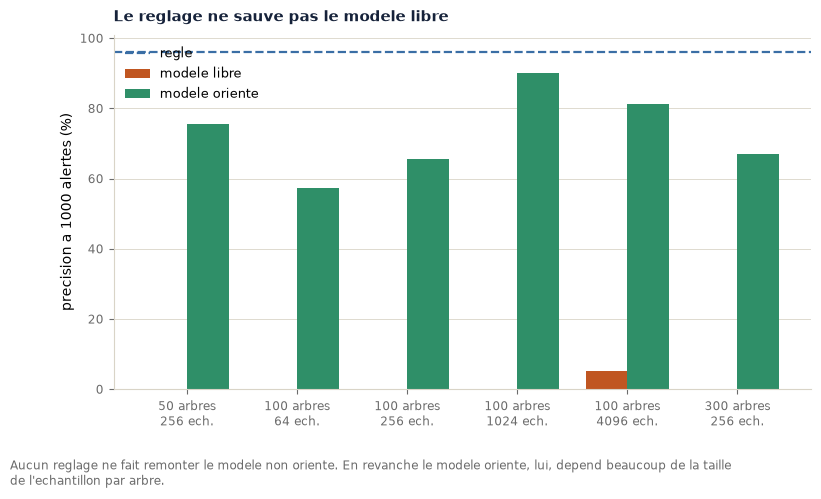

In [27]:
figure, axes = plt.subplots(figsize=(9, 4.6))
position = np.arange(len(sensibilite))
axes.bar(
    position - 0.19, sensibilite["precision libre (%)"], 0.38, color=SERIE_2, label="modele libre"
)
axes.bar(
    position + 0.19,
    sensibilite["precision oriente (%)"],
    0.38,
    color=SERIE_3,
    label="modele oriente",
)
axes.axhline(
    precision_au_budget(score_regle, etiquettes, BUDGET_DE_REFERENCE),
    color=SERIE_1,
    linewidth=1.6,
    linestyle="--",
    label="regle",
)

axes.set_xticks(position)
axes.set_xticklabels(
    [
        f"{a} arbres\n{e} ech."
        for a, e in zip(sensibilite["arbres"], sensibilite["echantillon par arbre"], strict=True)
    ],
    fontsize=8,
)
axes.set_ylabel(f"precision a {BUDGET_DE_REFERENCE} alertes (%)")
axes.legend(frameon=False, fontsize=9)
soigner(axes, "Le reglage ne sauve pas le modele libre")
legender(
    figure,
    "Aucun reglage ne fait remonter le modele non oriente. En revanche le modele "
    "oriente, lui, depend beaucoup de la taille\nde l'echantillon par arbre.",
)
plt.show()

Deux constats opposés dans le même tableau.

**Pour le modèle libre, le réglage ne change rien** : il reste au plancher sur toute la grille. La
conclusion des sections 4 à 6 ne dépend donc pas d'un mauvais choix d'hyperparamètre, elle tient à
la direction de recherche.

**Pour le modèle orienté, le réglage compte beaucoup.** La valeur recommandée par les auteurs de la
méthode, 256 échantillons par arbre, n'est pas la meilleure ici : 1024 fait nettement mieux. Un
défaut de bibliothèque reste un défaut, pas une vérité.

Même à son meilleur réglage, le modèle orienté reste sous la règle. Cela ne change donc pas la
décision, mais cela change ce qu'on peut en dire : si le modèle devait un jour servir, il faudrait
régler `max_samples` sur mesure, et ce réglage devrait être refait à chaque changement de données.
Une règle, elle, n'a rien à régler.

## 9. Bilan

### La décision

**Les règles restent la méthode de détection du projet.** La justification a changé deux fois en
cours de route, et c'est la dernière qui compte.

> Sur dix méthodes, aucune n'a dépassé une statistique descriptive tenant en une ligne de SQL. Les
> modèles ne trouvent des valeurs extrêmes qu'une fois qu'on leur a dit de quel côté regarder, et
> cette connaissance vient du métier, pas des données. Une règle la porte en clair et l'explique à
> l'utilisateur ; un modèle ne l'a que si on la lui impose de l'extérieur, et il ne peut alors plus
> rien expliquer de sa décision.

Avec une réserve qu'il faut énoncer plutôt que taire : **l'étiquette disponible ne sait pas
départager les variantes de la règle.** Elle départage les directions de recherche, pas la finesse
du calcul. Le choix de la version robuste repose donc sur un argument de méthode, pas sur une
mesure, tant qu'un échantillon n'aura pas été jugé à la main.

Ce qui est conservé du modèle : les marchés anormalement **bas** qu'il désigne, affichés avec la
mention « non évalué ». Un marché de travaux à un euro mérite un regard même si aucune étiquette ne
le confirme.

### Les fausses pistes, avec leur chiffre

| Ce que j'ai fait | Ce que ça donnait | Ce qui n'allait pas | Après correction |
|---|---|---|---|
| écart en valeur absolue, les deux sens mélangés | 23,8 % | le sens « trop bas » ne concorde jamais : 0 sur 18 208 | **75,8 %** |
| lire le 0 % du modèle comme « mauvais modèle » | 0 % | la métrique mesurait un désaccord de direction | section 6 |
| croire qu'une graine fixe suffit | 100 % puis 74 % au même code | pas d'ordre de lignes garanti, et `uid` n'est pas unique | section 3 |
| annoncer que le robuste battrait le naïf | le naïf fait un peu mieux | l'étiquette ne sait pas départager ces variantes | section 7 |
| écarter LOF sur sa réputation de coût quadratique | durée par ligne constante | en cinq dimensions, l'arbre rend la recherche quasi linéaire | méthode 10 du banc |
| juger les titulaires sur les 150 plus gros | 11,7 % de PME | échantillon biaisé par construction | **58,9 %**, contre 60 % publiés |
| additionner les montants bruts | 3 030 Md€ par an | doublons et montants aberrants | **233 Md€** |

Aucune n'était une erreur de code : le code faisait ce qu'on lui demandait. Cinq fois sur sept,
c'était une conclusion écrite avant d'avoir regardé la mesure. Les deux autres venaient d'une idée
reçue reprise sans la vérifier. D'où la règle que je m'applique maintenant : **quand un chiffre
surprend, ouvrir les lignes avant d'écrire la conclusion, et ne jamais écarter une option sans
l'avoir mesurée.**

### Ce qui passe en script

`mesures/modele_vs_regles.py`, lancé par `make bench-modele`, garde la préparation SQL, les quatre
méthodes et le protocole. Le reste, diagnostic et graphiques, reste ici. Vérifions qu'il n'y a pas
deux vérités.

In [28]:
from mesures.modele_vs_regles import PREPARATION
from mesures.modele_vs_regles import VARIABLES as VARIABLES_SCRIPT

con.execute(PREPARATION)
jeu_script = con.sql(
    "select * from jeu"
    " order by uid, montant_log10, ecart_normalise, montant_par_mois_log10,"
    " duree_mois, offres_recues, signale_par_le_producteur"
).df()

colonnes = [
    "signale_par_le_producteur",
    "montant_log10",
    "duree_mois",
    "offres_recues",
    "ecart_normalise",
    "montant_par_mois_log10",
]
print(f"memes variables : {VARIABLES_SCRIPT == VARIABLES}")
print(f"memes lignes    : {len(jeu_script) == len(jeu)}")
print(
    "memes valeurs   : "
    + str(
        all(
            np.allclose(
                jeu[c].to_numpy(dtype=float),
                jeu_script[c].to_numpy(dtype=float),
                rtol=1e-9,
                atol=1e-9,
                equal_nan=True,
            )
            for c in colonnes
        )
    )
)

memes variables : True
memes lignes    : True
memes valeurs   : True


### À mesurer ensuite

1. Faire juger à la main un échantillon de marchés désignés par chacune des trois statistiques,
   pour obtenir une étiquette qui ne vienne pas d'un détecteur de montants. C'est la seule façon de
   départager la règle robuste de ses versions naïves, et donc de justifier le choix actuel par une
   mesure plutôt que par un raisonnement.
2. Mesurer l'apport des quatre variables autres que l'écart : le modèle orienté fait-il mieux que
   l'écart seul, ou seulement aussi bien ?
3. Reprendre la comparaison sur le signal d'offre unique, qui ne dépend pas du montant.